In [2]:
!pip install augmentation
"""
Documentation: https://albumentations.ai
Albumentations provides a flexible and powerful API for image augmentation. The core of the library is the Compose class, 
which allows you to chain multiple image transformations together. Each transformation is defined using a dedicated class, 
such as HorizontalFlip, RandomBrightnessContrast, or Perspective.
"""

'\nDocumentation: https://albumentations.ai\nAlbumentations provides a flexible and powerful API for image augmentation. The core of the library is the Compose class, \nwhich allows you to chain multiple image transformations together. Each transformation is defined using a dedicated class, \nsuch as HorizontalFlip, RandomBrightnessContrast, or Perspective.\n'

In [3]:
# This is taken from the albumentations library itself
"""
1. To have reproducible augmentations, set the seed parameter in your transform pipeline. This will ensure that the same random parameters are used for each augmentation, resulting in the same output for the same input.
2. How can I find which augmentations were applied to the input data and which parameters they used?
You may pass save_applied_params=True to Compose to save the parameters of the applied augmentations. You can access them later using applied_transforms.
3. 
"""

"""
How to choose augmentations
1. Add Incrementally: Don't add dozens of transforms at once. Start with a basic set (like cropping and flips) and add new augmentations one by one or in small groups. Monitor your validation metric (loss, accuracy, F1-score, etc.) after adding each new augmentation. If the metric improves, keep it; if it worsens or stays the same, reconsider or remove it.
2. Parameter Tuning is Empirical: There's no single formul to determine the best parameters (e.g., rotation angle, dropout probability, brightness limit) for an augmentation. Choosing good parameters relies heavily on domain knowledge, experience, and experimentation. What works well for one dataset might not work for another.
3. Visualize Your Augmentations: Always visualize the output of your augmentation pipeline on sample images from your dataset. This is crucial to ensure the augmented images are still realistic and don't distort the data in ways that would harm learning
Here is the link to check for transofmrations: https://explore.albumentations.ai
https://albumentations.ai/docs/3-basic-usage/choosing-augmentations/
"""
# Keep miminal augmentation for validation set.
"""
'Scale': A.RandomScale(scale_limit=0.2, p=1.0),
A.Perspective(scale=(0.02, 0.05), p=1.0)
A.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.15, hue=0.05, p=0.8),
A.HorizontalFlip(p=0.5),
A.Rotate(limit=5, p=0.3),  # More conservative
A.MotionBlur(blur_limit=3, p=0.2)

"""


"\n'Scale': A.RandomScale(scale_limit=0.2, p=1.0),\n'Minimal_Perspective': A.Perspective(scale=(0.02, 0.05), p=1.0)\nRotation_8deg': A.Rotate(limit=8, border_mode=cv2.BORDER_REFLECT, p=1.0)\n"

In [4]:
# Augmentation code from supervision website
import albumentations as A

augmentation = A.Compose(
    transforms=[
        A.Perspective(p=0.1),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.5)
    ],
    bbox_params=A.BboxParams(
        format='pascal_voc',
        label_fields=['category']
    ),
)
#The key is to set format='pascal_voc', which corresponds to the [x_min, y_min, x_max, y_max] bounding box format used in Supervision.

import numpy as np
import supervision as sv
from dataclasses import replace

ds = sv.DetectionDataset(...)

_, original_image, original_annotations = ds[0]

output = augmentation(
    image=original_image,
    bboxes=original_annotations.xyxy,
    category=original_annotations.class_id
)

augmented_image = output['image']
augmented_annotations = replace(
    original_annotations,
    xyxy=np.array(output['bboxes']),
    class_id=np.array(output['category'])
)

TypeError: DetectionDataset.__init__() missing 2 required positional arguments: 'images' and 'annotations'

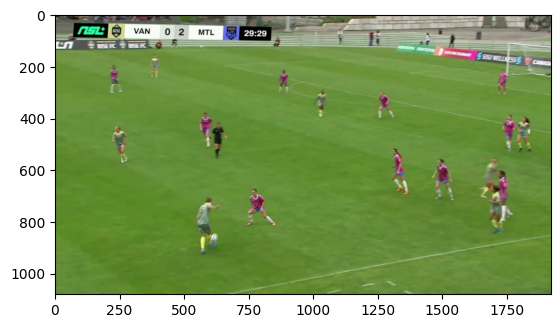

In [5]:
import albumentations as A
import numpy as np
import matplotlib.pyplot as plt
import cv2


# Assume 'image' is loaded as a NumPy array (e.g., 100x100x3)
# image = np.random.randint(0, 256, (100, 100, 3), dtype=np.uint8) # Dummy image
cap = cv2.VideoCapture('/Users/spectatr/Downloads/data_testing/model_training_data/outlier_video.mp4')
cap.set(cv2.CAP_PROP_POS_FRAMES, 120)
ret, image = cap.read()
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
# plt.imshow(image)
# 1. Define the pipeline
# cv2.imwrite('/Users/spectatr/Downloads/general_scripts/image.jpg', image)
pipeline = A.Compose([
    # A.HorizontalFlip(p=0.5), # 50% chance to flip
    # A.RandomBrightnessContrast(p=0.8), # 80% chance to adjust brightness/contrast
    # A.GaussianBlur(p=0.3), # 30% chance to blur
    A.Perspective(scale=(0.02, 0.05), p=1.0)
])

# 2. Apply the pipeline
transformed_data = pipeline(image=rgb_image)
transformed_image = transformed_data['image']
plt.imshow(transformed_image)
# print(f"Original shape: {image.shape}, Transformed shape: {transformed_image.shape}")

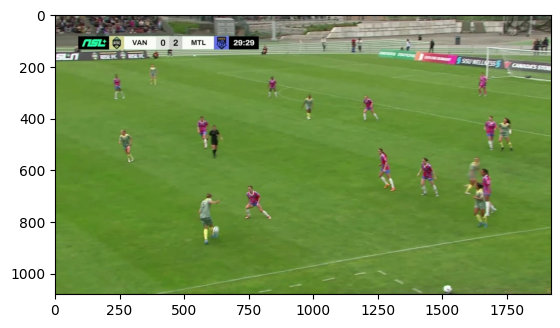

In [6]:
plt.imshow(rgb_image)